In [1]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, Conv2DTranspose, BatchNormalization, Activation, AveragePooling2D

In [2]:
# Define Preprocessor
def pre_block(inputs):
    s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)
    
    incep1 = Conv2D(12, (1,1), activation='relu', kernel_initializer='he_normal', padding='same')(s)

    incep2 = Conv2D(12, (1,1), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    incep2 = Conv2D(12, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(incep2)

    incep3 = Conv2D(12, (1,1), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    incep3 = Conv2D(12, (5,5), activation='relu', kernel_initializer='he_normal', padding='same')(incep3)

    incep4 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding="same")(s)
    incep4 = Conv2D(12, (1,1), activation='relu', kernel_initializer='he_normal', padding='same')(incep4)
    
    incep5 = AveragePooling2D(pool_size=(3, 3), strides=(1, 1), padding="same")(s)
    incep5 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding="same")(incep5)
    incep5 = Conv2D(12, (1,1), activation='relu', kernel_initializer='he_normal', padding='same')(incep5)
    
    incep_res = concatenate([incep1, incep2, incep3, incep4, incep5])
    
    incep_res = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(incep_res)
    
    return incep_res

In [3]:
# Define Convolutional Block
def conv_block(input, num_filters):
    x = Conv2D(num_filters, 3, padding = "same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    
    x = Conv2D(num_filters, 3, padding = "same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    
    return x

In [4]:
# Define Encoder
def encoder_block(input, num_filters):
    x = conv_block(input, num_filters)
    p = MaxPooling2D((2,2))(x)
    return x, p

In [5]:
# Define Decoder
def decoder_block(input, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2,2), strides = 2, padding = "same")(input)
    x = concatenate([x, skip_features])
    x = conv_block(x, num_filters)
    return x

In [6]:
# Define Network
def build_unet(input_shape):
    inputs = Input(input_shape)
    
    t = pre_block(inputs)

    s1, p1 = encoder_block(t, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b1 = conv_block(p4, 512)

    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)
    
    outputs = Conv2D(1,1, padding = "same", activation = "sigmoid")(d4)
    
    model = Model(inputs, outputs, name = "U-Net")
    return model

In [7]:
import tensorflow as tf
import os
from pathlib import Path
import numpy as np
from tqdm import tqdm
from skimage import color
from skimage.io import imread, imshow
from skimage.transform import resize
import matplotlib.pyplot as plt
import random

In [8]:
# Test for GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

Num GPUs Available:  1


In [9]:
# Define Training Set & Testing Set
IMG_WIDTH = 448
IMG_HEIGHT = 448
IMG_CHANNELS = 3
Train_X_dir = Path(r'C:\Users\tenso\Downloads\Group_Project\Brightlife\Crack500\images')
Train_Y_dir = Path(r'C:\Users\tenso\Downloads\Group_Project\Brightlife\Crack500\masks')
Test_X_dir = Path(r'C:\Users\tenso\Downloads\Group_Project\Brightlife\Test')
Train_X_ids = next(os.walk(Train_X_dir))[2]
Train_Y_ids = next(os.walk(Train_Y_dir))[2]
Test_X_ids = next(os.walk(Test_X_dir))[2]
Train_X_path = 'Crack500/images/'
Train_Y_path = 'Crack500/masks/'
Test_X_path = 'Test/'
Train_X = np.zeros((len(Train_X_ids), IMG_HEIGHT, IMG_WIDTH,3), dtype=np.uint8)
Train_Y = np.zeros((len(Train_Y_ids), IMG_HEIGHT, IMG_WIDTH,1), dtype=bool)
Test_X = np.zeros((len(Test_X_ids), IMG_HEIGHT, IMG_WIDTH,3), dtype=np.uint8)
for n, id_ in tqdm(enumerate(Train_X_ids), total=len(Train_X_ids)):
    print(id_)
    img_paths = Train_X_path + id_
    img = imread(img_paths)[:,:,:IMG_CHANNELS]
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    Train_X[n] = img
    msk_paths = Train_Y_path + id_
    msk = imread(msk_paths)[:,:]
    msk = resize(msk, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    msk = np.expand_dims(msk,axis=-1)
    Train_Y[n]=msk
    

sizes_test = []
for n, id_ in tqdm(enumerate(Test_X_ids), total=len(Test_X_ids)):
    print(id_)
    img_paths = Test_X_path + id_
    img = imread(img_paths)[:,:,:IMG_CHANNELS]
    sizes_test.append([img.shape[0], img.shape[1]])
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    # img = color.rgb2gray(img)
    Test_X[n] = img

  1%|          | 2/240 [00:00<00:13, 17.28it/s]

CRACK500_20160222_080850_1281_361.jpg
CRACK500_20160222_080850_1281_721.jpg
CRACK500_20160222_080850_1921_1.jpg
CRACK500_20160222_080850_1921_361.jpg


  2%|▎         | 6/240 [00:00<00:17, 13.72it/s]

CRACK500_20160222_080850_1_361.jpg
CRACK500_20160222_080850_641_361.jpg
CRACK500_20160222_080850_641_721.jpg


  4%|▍         | 10/240 [00:00<00:15, 14.40it/s]

...

CRACK500_20160222_163940_641_1.jpg
CRACK500_20160222_163940_641_1081.jpg
CRACK500_20160308_155720_1281_1.jpg


 75%|███████▌  | 9/12 [00:00<00:00, 23.34it/s]

CRACK500_20160330_163855_641_1.jpg
cracktree200_6280.jpg


100%|██████████| 12/12 [00:00<00:00, 23.17it/s]

DeepCrack_11123-3.jpg
GAPS384_train_0680_541_641.jpg


In [10]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [18]:
# Model Hyperparameters
model = build_unet(input_shape)
model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics = ['Accuracy'])

In [19]:
model.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 448, 448, 3  0           []                               
                                )]                                                                
                                                                                                  
 lambda_1 (Lambda)              (None, 448, 448, 3)  0           ['input_2[0][0]']                
                                                                                                  
 average_pooling2d_1 (AveragePo  (None, 448, 448, 3)  0          ['lambda_1[0][0]']               
 oling2D)                                                                                         
                                                                                              

                                                                                                  
 max_pooling2d_9 (MaxPooling2D)  (None, 112, 112, 64  0          ['activation_21[0][0]']          
                                )                                                                 
                                                                                                  
 conv2d_39 (Conv2D)             (None, 112, 112, 12  73856       ['max_pooling2d_9[0][0]']        
                                8)                                                                
                                                                                                  
 batch_normalization_22 (BatchN  (None, 112, 112, 12  512        ['conv2d_39[0][0]']              
 ormalization)                  8)                                                                
                                                                                                  
 activatio

                                8)                                                                
                                                                                                  
 batch_normalization_30 (BatchN  (None, 112, 112, 12  512        ['conv2d_47[0][0]']              
 ormalization)                  8)                                                                
                                                                                                  
 activation_30 (Activation)     (None, 112, 112, 12  0           ['batch_normalization_30[0][0]'] 
                                8)                                                                
                                                                                                  
 conv2d_48 (Conv2D)             (None, 112, 112, 12  147584      ['activation_30[0][0]']          
                                8)                                                                
          

In [20]:
# Train
checkpointer = tf.keras.callbacks.ModelCheckpoint('crack_seg.h5', verbose=1, save_best_only=True)
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=9),
            tf.keras.callbacks.TensorBoard(log_dir='logs')]
result = model.fit(Train_X,Train_Y, validation_split=0.3, batch_size=4, epochs=100, callbacks=callbacks)

Epoch 1/100
42/42 [==============================] - 13s 253ms/step - loss: 0.4101 - Accuracy: 0.8916 - val_loss: 5179.4004 - val_Accuracy: 0.0603
Epoch 2/100
42/42 [==============================] - 10s 242ms/step - loss: 0.2156 - Accuracy: 0.9726 - val_loss: 3.4814 - val_Accuracy: 0.5916
Epoch 3/100
42/42 [==============================] - 10s 242ms/step - loss: 0.1592 - Accuracy: 0.9727 - val_loss: 0.2849 - val_Accuracy: 0.9370
Epoch 4/100
42/42 [==============================] - 10s 245ms/step - loss: 0.1374 - Accuracy: 0.9725 - val_loss: 0.2940 - val_Accuracy: 0.9440
Epoch 5/100
42/42 [==============================] - 10s 244ms/step - loss: 0.1150 - Accuracy: 0.9733 - val_loss: 0.9959 - val_Accuracy: 0.1265
Epoch 6/100
42/42 [==============================] - 10s 244ms/step - loss: 0.1047 - Accuracy: 0.9732 - val_loss: 0.1952 - val_Accuracy: 0.9481
Epoch 7/100
42/42 [==============================] - 10s 245ms/step - loss: 0.0987 - Accuracy: 0.9727 - val_loss: 0.1315 - val_Accura

In [21]:
# Predict
preds_test = model.predict(Test_X, verbose=1)

1/1 [==============================] - 1s 583ms/step


In [22]:
# Step Function (not necessary)
preds_test_t = (preds_test > 0.5).astype(np.uint8)

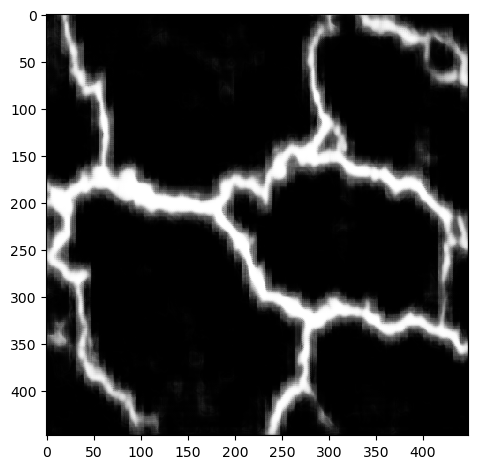

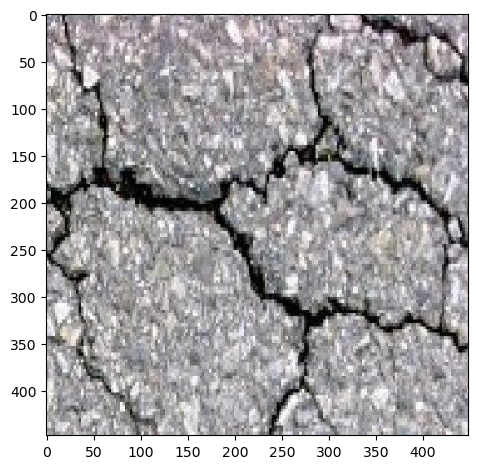

In [34]:
# Show Result
a=10
imshow(preds_test[a])
plt.show()
imshow(Test_X[a])

In [35]:
# Test for Other Sets
Test_P_dir = Path(r'C:\Users\tenso\Downloads\Group_Project\Brightlife\images')
Test_P_ids = next(os.walk(Test_P_dir))[2]
Test_P_path = 'images/'
Test_P = np.zeros((len(Test_P_ids), IMG_HEIGHT, IMG_WIDTH,3), dtype=np.uint8)

sizes_test = []
for n, id_ in tqdm(enumerate(Test_P_ids), total=len(Test_P_ids)):
    print(id_)
    img_paths = Test_P_path + id_
    img = imread(img_paths)[:,:,:IMG_CHANNELS]
    sizes_test.append([img.shape[0], img.shape[1]])
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    # img = color.rgb2gray(img)
    Test_P[n] = img

 12%|█▎        | 2/16 [00:00<00:00, 17.58it/s]

CFD_001.jpg
CFD_005.jpg
CFD_018.jpg
CFD_069.jpg
CFD_072.jpg


 44%|████▍     | 7/16 [00:00<00:00, 17.70it/s]

CFD_086.jpg
CFD_090.jpg
CFD_100.jpg
CFD_111.jpg
CFD_112.jpg


 81%|████████▏ | 13/16 [00:00<00:00, 20.84it/s]

CFD_118.jpg
CRACK500_20160329_104031_641_1.jpg
CRACK500_20160329_104107_1_721.jpg
CRACK500_20160329_104107_641_1.jpg
CRACK500_20160329_104107_641_721.jpg


100%|██████████| 16/16 [00:00<00:00, 19.81it/s]

CRACK500_20160329_104111_1281_721.jpg


In [36]:
preds_test_P = model.predict(Test_P, verbose=1)

1/1 [==============================] - 3s 3s/step


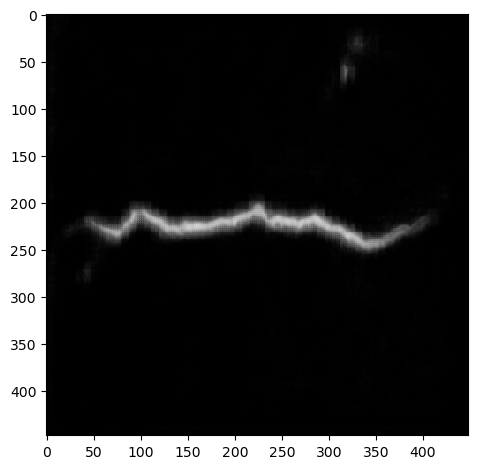

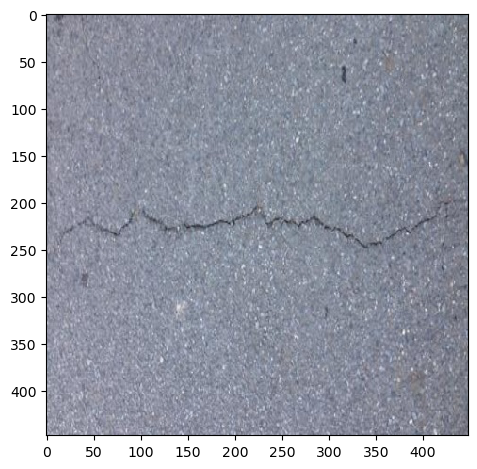

In [50]:
a=8
imshow(preds_test_P[a])
plt.show()
imshow(Test_P[a])